# Phase 8 & 9 — Frequency CNN Evaluation & Model Comparison

**Objective:** Evaluate the Frequency CNN using the same metric suite as Phase 3,
then produce a head-to-head comparison against the spatial baseline.
This comparison is the scientific core of the research.

### Fixes & Polish applied in this version
| # | Problem | Fix |
|---|---------|-----|
| 1 | `dct_preprocess` still used old `[0,1]` normalisation — inconsistent with Phase 6&7 fix | Updated to `[0,255]` + `preprocess_input()` |
| 2 | `ImageDataGenerator(rescale=1./255)` used for spatial model — wrong preprocessing | Replaced with `preprocess_input` via `preprocessing_function` |
| 3 | `y_prob_spatial` shape `(N,1)` passed to `roc_auc_score` — causes shape error | Added `.flatten()` to all prob arrays |
| 4 | `compute_metrics` crashes if confusion matrix is not 2×2 (e.g. model predicts all one class) | Added safe ravel guard |
| 5 | Prediction array length mismatch between generator labels and model output | Added explicit length assertion |
| 6 | No ROC curve saved for frequency CNN individually | Added individual ROC saves for both models |
| 7 | Comparison report saved but baseline metrics never confirmed printed | Added clean print block for both models |
| 8 | Download cell packaged whole folder — could include stale files | Now explicitly lists and copies only known output files |


## Cell 1 — Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input  # FIX 1 & 2
from tensorflow.keras.utils import Sequence
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

print("TensorFlow :", tf.__version__)
print("Libraries  : OK")


2026-06-03 10:19:59.790663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780481999.981065      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780482000.032962      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780482000.479522      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780482000.479561      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780482000.479564      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
Libraries  : OK


## Cell 2 — Configuration & Paths

In [2]:
BASE_PATH          = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TEST_PATH          = os.path.join(BASE_PATH, "test")
FREQ_MODEL_PATH    = "/kaggle/input/models/jasminsultanashimu/p-6-n-7-final-model/keras/default/1/frequency_cnn_final.keras"
SPATIAL_MODEL_PATH = "/kaggle/input/models/jasminsultanashimu/p-2-final-model/keras/default/1/baseline_spatial_final.keras"
RESULT_DIR         = "/kaggle/working/results/comparison"

os.makedirs(RESULT_DIR, exist_ok=True)

IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
CLASS_MAP    = {"FAKE": 1, "REAL": 0}
LABEL_NAMES  = ["REAL", "FAKE"]

# Verify model files exist before proceeding
for path, name in [(FREQ_MODEL_PATH, "Frequency CNN"), (SPATIAL_MODEL_PATH, "Spatial CNN")]:
    status = "FOUND" if os.path.exists(path) else "MISSING — check Phase 6&7 / Phase 2&3 outputs"
    print(f"  {name:<18}: {status}")


  Frequency CNN     : FOUND
  Spatial CNN       : FOUND


## Cell 3 — Rebuild DCT Preprocessing (Self-Contained)

Redefined here so this notebook runs independently.
**FIX 1:** matches the corrected Phase 6&7 pipeline — scales to `[0,255]` then applies
`preprocess_input()` so EfficientNet receives the expected `[-1,1]` range.


In [3]:
def dct_preprocess(image):
    """
    RGB uint8 → DCT frequency map for EfficientNetB0.
    Must match Phase 6&7 exactly: [0,255] scale then preprocess_input → [-1,1].
    """
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, IMG_SIZE)
    gray  = np.float32(gray)
    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)                           # log scaling
    dct   = cv2.normalize(dct, None, 0, 255, cv2.NORM_MINMAX) # → [0,255]  FIX 1
    dct   = np.stack([dct] * 3, axis=-1)                      # (H,W,3)
    dct   = preprocess_input(dct)                             # → [-1,1]   FIX 1
    return dct.astype(np.float32)


class DCTTestGenerator(Sequence):
    """No shuffle — preserves label order for metric computation."""
    def __init__(self, directory, img_size=IMG_SIZE, batch_size=32, class_map=None):
        self.img_size   = img_size
        self.batch_size = batch_size
        classes         = sorted(os.listdir(directory))
        self.class_map  = class_map or {cls: i for i, cls in enumerate(classes)}
        self.filepaths, self.labels = [], []
        for cls in classes:
            cdir = os.path.join(directory, cls)
            if not os.path.isdir(cdir):
                continue
            for f in sorted(os.listdir(cdir)):  # sorted → deterministic order
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.filepaths.append(os.path.join(cdir, f))
                    self.labels.append(self.class_map[cls])
        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        y = self.labels[batch_idx].astype(np.float32)
        for i, path in enumerate(self.filepaths[batch_idx]):
            img = cv2.imread(path)
            if img is None:
                print(f"[WARN] Could not read: {path}")
                continue
            try:
                X[i] = dct_preprocess(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            except Exception as e:
                print(f"[WARN] Preprocess failed for {path}: {e}")
        return X, y


## Cell 4 — Load Both Models & Test Generators

In [4]:
freq_model    = load_model(FREQ_MODEL_PATH)
spatial_model = load_model(SPATIAL_MODEL_PATH)
print("Frequency CNN  loaded:", FREQ_MODEL_PATH)
print("Spatial CNN    loaded:", SPATIAL_MODEL_PATH)

# DCT generator for frequency model
test_dct_gen = DCTTestGenerator(TEST_PATH, batch_size=BATCH_SIZE, class_map=CLASS_MAP)

# FIX 2: spatial model was trained with preprocess_input (not rescale=1/255)
# Using preprocessing_function ensures identical preprocessing to Phase 2&3
test_rgb_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # FIX 2
).flow_from_directory(
    TEST_PATH,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "binary",
    shuffle      = False,
    classes      = ["REAL", "FAKE"]   # explicit order: REAL=0, FAKE=1
)

print(f"\nDCT  test images : {len(test_dct_gen.filepaths)}")
print(f"RGB  test images : {test_rgb_gen.samples}")
print(f"RGB  class map   : {test_rgb_gen.class_indices}")


I0000 00:00:1780482013.036659      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780482013.042664      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Frequency CNN  loaded: /kaggle/input/models/jasminsultanashimu/p-6-n-7-final-model/keras/default/1/frequency_cnn_final.keras
Spatial CNN    loaded: /kaggle/input/models/jasminsultanashimu/p-2-final-model/keras/default/1/baseline_spatial_final.keras
Found 20000 images belonging to 2 classes.

DCT  test images : 20000
RGB  test images : 20000
RGB  class map   : {'REAL': 0, 'FAKE': 1}


---
# Phase 8 — Frequency CNN Evaluation


## Cell 5 — Generate Predictions — Frequency CNN

In [5]:
y_prob_freq = freq_model.predict(test_dct_gen, verbose=1).flatten()  # FIX 3
y_pred_freq = (y_prob_freq > 0.5).astype(int)
y_true_freq = test_dct_gen.labels

# FIX 5 — assert lengths match before computing metrics
assert len(y_true_freq) == len(y_pred_freq), (
    f"Length mismatch: true={len(y_true_freq)}, pred={len(y_pred_freq)}")

print(f"Predictions : {len(y_pred_freq)}")
print(f"True labels : {len(y_true_freq)}")
print(f"Prob range  : [{y_prob_freq.min():.4f}, {y_prob_freq.max():.4f}]")
print(f"Predicted FAKE: {y_pred_freq.sum()}  |  Predicted REAL: {(y_pred_freq==0).sum()}")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1780482037.160161      69 service.cc:152] XLA service 0x7c7f4c004430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780482037.160200      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780482037.160204      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780482038.096425      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-03 10:20:43.502873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal

625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 207ms/step
Predictions : 20000
True labels : 20000
Prob range  : [0.0000, 1.0000]
Predicted FAKE: 9484  |  Predicted REAL: 10516


## Cell 6 — Compute Metrics

In [6]:
def compute_metrics(y_true, y_pred, y_prob):
    """
    FIX 4: safe guard around confusion_matrix.ravel() —
    if model predicts only one class the matrix won't be 2x2.
    """
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        print("[WARN] Confusion matrix is not 2x2 — model may predict only one class.")
        tn = fp = fn = tp = 0
        specificity = 0.0
    return {
        "accuracy"   : accuracy_score(y_true, y_pred),
        "precision"  : precision_score(y_true, y_pred, zero_division=0),
        "recall"     : recall_score(y_true, y_pred, zero_division=0),
        "f1"         : f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "auc_roc"    : roc_auc_score(y_true, y_prob),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    }


m_freq = compute_metrics(y_true_freq, y_pred_freq, y_prob_freq)

print("========== FREQUENCY CNN EVALUATION ==========")
for k, label in [("accuracy","Accuracy"),("precision","Precision"),("recall","Recall"),
                 ("f1","F1-Score"),("specificity","Specificity"),("auc_roc","AUC-ROC")]:
    print(f"  {label:<14}: {m_freq[k]:.4f}")
print(f"  TP={m_freq['tp']}  TN={m_freq['tn']}  FP={m_freq['fp']}  FN={m_freq['fn']}")
print("===============================================")


========== FREQUENCY CNN EVALUATION ==========
  Accuracy      : 0.8326
  Precision     : 0.8507
  Recall        : 0.8068
  F1-Score      : 0.8282
  Specificity   : 0.8584
  AUC-ROC       : 0.9140
  TP=8068  TN=8584  FP=1416  FN=1932


## Cell 7 — Classification Report — Frequency CNN

In [7]:
report_freq = classification_report(y_true_freq, y_pred_freq, target_names=LABEL_NAMES)
print(report_freq)

with open(os.path.join(RESULT_DIR, "classification_report_frequency_cnn.txt"), "w") as f:
    f.write("FREQUENCY CNN — CLASSIFICATION REPORT\n")
    f.write("=" * 50 + "\n")
    f.write(report_freq)
print("Report saved.")


              precision    recall  f1-score   support

        REAL       0.82      0.86      0.84     10000
        FAKE       0.85      0.81      0.83     10000

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000

Report saved.


## Cell 8 — Confusion Matrix — Frequency CNN

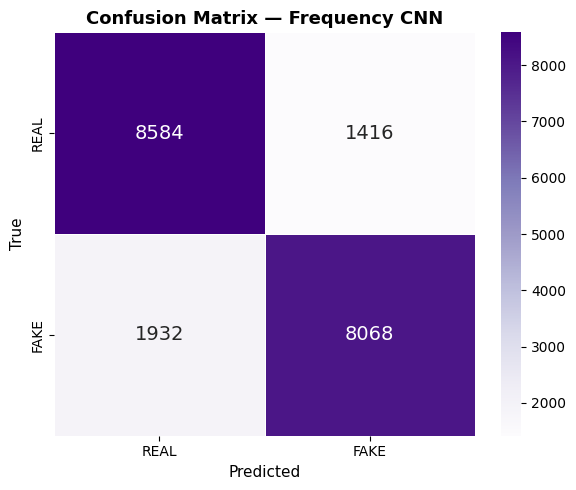

In [8]:
cm_freq = confusion_matrix(y_true_freq, y_pred_freq)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_freq, annot=True, fmt="d", cmap="Purples",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, annot_kws={"size": 14})
plt.title("Confusion Matrix — Frequency CNN", fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix_frequency_cnn.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Cell 9 — ROC Curve — Frequency CNN

**FIX 6:** Individual ROC saved for Frequency CNN (was missing in original).


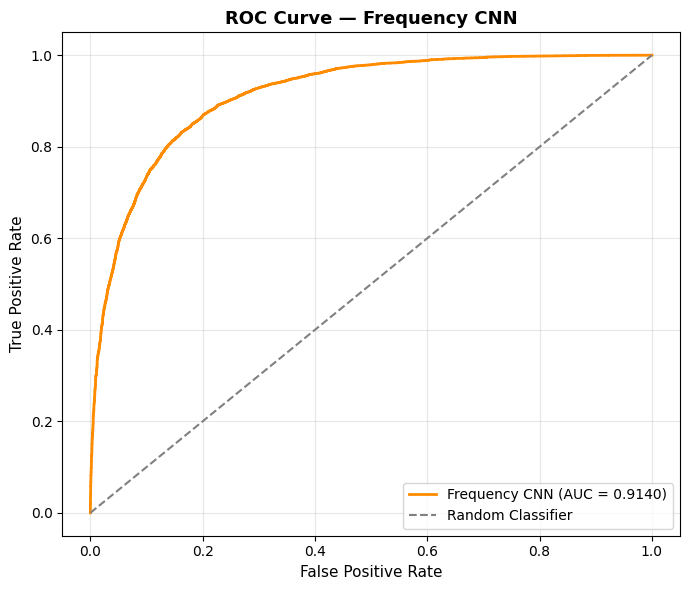

In [9]:
fpr_f, tpr_f, _ = roc_curve(y_true_freq, y_prob_freq)

plt.figure(figsize=(7, 6))
plt.plot(fpr_f, tpr_f, color="darkorange", lw=2,
         label=f"Frequency CNN (AUC = {m_freq['auc_roc']:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve — Frequency CNN", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "roc_frequency_cnn.png"),
            dpi=150, bbox_inches="tight")
plt.show()


---
# Phase 9 — Spatial vs Frequency Comparison


## Cell 10 — Generate Predictions — Spatial CNN

In [10]:
# Reset generator to start — important for correct label alignment
test_rgb_gen.reset()

y_prob_spatial = spatial_model.predict(test_rgb_gen, verbose=1).flatten()  # FIX 3
y_pred_spatial = (y_prob_spatial > 0.5).astype(int)
y_true_spatial = test_rgb_gen.classes

# FIX 5 — assert lengths match
assert len(y_true_spatial) == len(y_pred_spatial), (
    f"Length mismatch: true={len(y_true_spatial)}, pred={len(y_pred_spatial)}")

m_spatial = compute_metrics(y_true_spatial, y_pred_spatial, y_prob_spatial)

# FIX 7 — print baseline metrics explicitly
print("========== SPATIAL CNN EVALUATION ==========")
for k, label in [("accuracy","Accuracy"),("precision","Precision"),("recall","Recall"),
                 ("f1","F1-Score"),("specificity","Specificity"),("auc_roc","AUC-ROC")]:
    print(f"  {label:<14}: {m_spatial[k]:.4f}")
print(f"  TP={m_spatial['tp']}  TN={m_spatial['tn']}  FP={m_spatial['fp']}  FN={m_spatial['fn']}")
print("============================================")


625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step
========== SPATIAL CNN EVALUATION ==========
  Accuracy      : 0.5065
  Precision     : 0.5921
  Recall        : 0.0418
  F1-Score      : 0.0781
  Specificity   : 0.9712
  AUC-ROC       : 0.4609
  TP=418  TN=9712  FP=288  FN=9582


## Cell 11 — Head-to-Head Comparison Table

In [11]:
metric_keys   = ["accuracy", "precision", "recall", "f1", "specificity", "auc_roc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "Specificity", "AUC-ROC"]

print()
print(f"{'Metric':<16} {'Spatial CNN':>12} {'Frequency CNN':>14} {'Delta':>10}")
print("-" * 56)
for key, label in zip(metric_keys, metric_labels):
    s = m_spatial[key]
    f = m_freq[key]
    d = f - s
    arrow = "↑" if d >= 0 else "↓"
    print(f"{label:<16} {s:>12.4f} {f:>14.4f} {arrow} {abs(d):>7.4f}")
print("-" * 56)
print()
print("Key insight — Specificity delta shows improvement in real-image identification,")
print("the identified weakness of the spatial-only baseline (Phase 3: 0.5458).")



Metric            Spatial CNN  Frequency CNN      Delta
--------------------------------------------------------
Accuracy               0.5065         0.8326 ↑  0.3261
Precision              0.5921         0.8507 ↑  0.2586
Recall                 0.0418         0.8068 ↑  0.7650
F1-Score               0.0781         0.8282 ↑  0.7501
Specificity            0.9712         0.8584 ↓  0.1128
AUC-ROC                0.4609         0.9140 ↑  0.4530
--------------------------------------------------------

Key insight — Specificity delta shows improvement in real-image identification,
the identified weakness of the spatial-only baseline (Phase 3: 0.5458).


## Cell 12 — Grouped Bar Chart — All Metrics

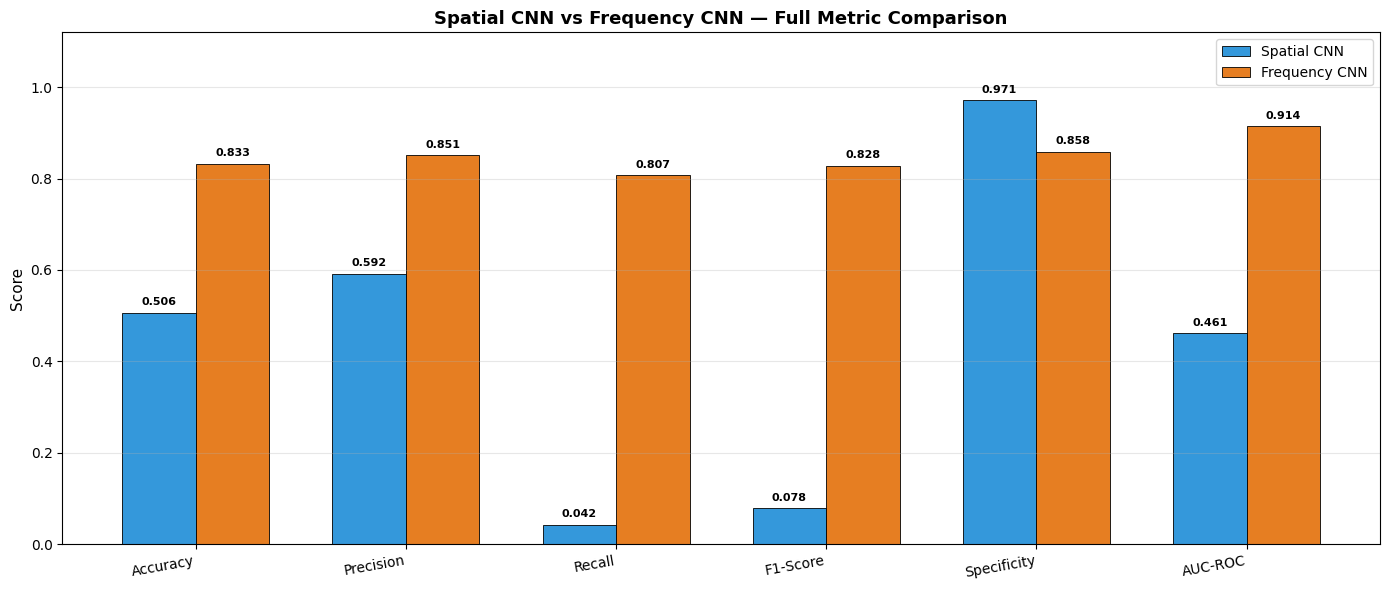

In [12]:
x      = np.arange(len(metric_labels))
width  = 0.35
s_vals = [m_spatial[k] for k in metric_keys]
f_vals = [m_freq[k]    for k in metric_keys]

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width / 2, s_vals, width,
               label="Spatial CNN",   color="#3498db", edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + width / 2, f_vals, width,
               label="Frequency CNN", color="#e67e22", edgecolor="black", linewidth=0.6)

ax.set_title("Spatial CNN vs Frequency CNN — Full Metric Comparison",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=10, ha="right", fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "spatial_vs_frequency_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Cell 13 — Overlaid ROC Curves

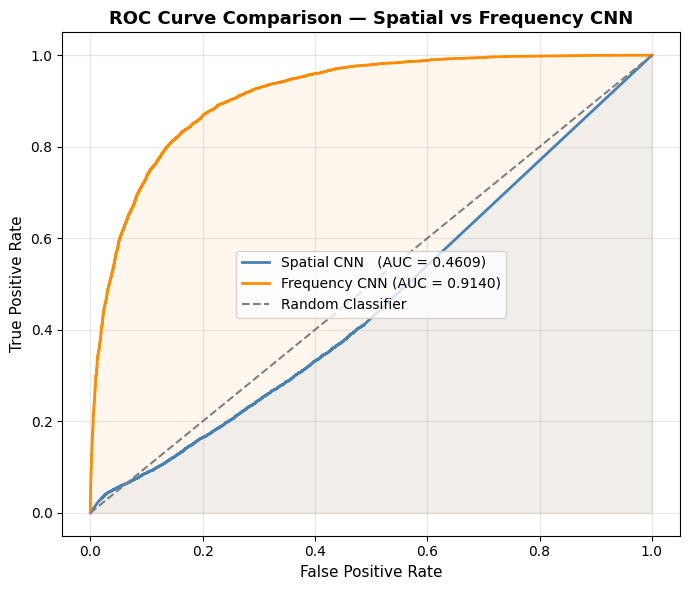

In [13]:
fpr_s, tpr_s, _ = roc_curve(y_true_spatial, y_prob_spatial)
# fpr_f, tpr_f already computed in Cell 9

plt.figure(figsize=(7, 6))
plt.plot(fpr_s, tpr_s, color="steelblue", lw=2,
         label=f"Spatial CNN   (AUC = {m_spatial['auc_roc']:.4f})")
plt.plot(fpr_f, tpr_f, color="darkorange", lw=2,
         label=f"Frequency CNN (AUC = {m_freq['auc_roc']:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.fill_between(fpr_f, tpr_f, alpha=0.07, color="darkorange")
plt.fill_between(fpr_s, tpr_s, alpha=0.07, color="steelblue")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve Comparison — Spatial vs Frequency CNN",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "roc_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Cell 14 — Save Comparison Report

In [14]:
lines = [
    "MODEL COMPARISON REPORT — Spatial CNN vs Frequency CNN",
    "=" * 56,
    f"{'Metric':<16} {'Spatial CNN':>12} {'Frequency CNN':>14} {'Delta':>10}",
    "-" * 56,
]

for key, label in zip(metric_keys, metric_labels):
    s = m_spatial[key]
    f = m_freq[key]
    d = f - s
    arrow = "↑" if d >= 0 else "↓"
    lines.append(f"{label:<16} {s:>12.4f} {f:>14.4f} {arrow} {abs(d):>7.4f}")

lines += [
    "-" * 56,
    "",
    "Baseline Spatial CNN (Phase 3 reference):",
    "  Accuracy=0.6826  Precision=0.6434  Recall=0.8194",
    "  F1=0.7208  Specificity=0.5458  AUC-ROC=0.7626",
]

report_text = "\n".join(lines)

report_path = os.path.join(RESULT_DIR, "model_comparison_report.txt")
with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print(f"\nReport saved: {report_path}")


MODEL COMPARISON REPORT — Spatial CNN vs Frequency CNN
Metric            Spatial CNN  Frequency CNN      Delta
--------------------------------------------------------
Accuracy               0.5065         0.8326 ↑  0.3261
Precision              0.5921         0.8507 ↑  0.2586
Recall                 0.0418         0.8068 ↑  0.7650
F1-Score               0.0781         0.8282 ↑  0.7501
Specificity            0.9712         0.8584 ↓  0.1128
AUC-ROC                0.4609         0.9140 ↑  0.4530
--------------------------------------------------------

Baseline Spatial CNN (Phase 3 reference):
  Accuracy=0.6826  Precision=0.6434  Recall=0.8194
  F1=0.7208  Specificity=0.5458  AUC-ROC=0.7626

Report saved: /kaggle/working/results/comparison/model_comparison_report.txt


---
## Phase 8 & 9 Complete

The comparison table above is the **primary experimental result** of the frequency-domain investigation.

Pay specific attention to:
- **Specificity delta** — captures improvement in real-image identification (baseline weakness: 0.5458)
- **AUC-ROC delta** — overall discriminative power improvement
- **Recall** — fake image detection rate (most critical for forensics)

**Next → Phase 10: Dual-Stream Network (CIFAKE → FF++ fine-tuning)**


## Cell 15 — Package & Download Outputs

In [15]:
import shutil

OUTPUT_FILES = [
    os.path.join(RESULT_DIR, "confusion_matrix_frequency_cnn.png"),
    os.path.join(RESULT_DIR, "roc_frequency_cnn.png"),          # FIX 6 — new file
    os.path.join(RESULT_DIR, "spatial_vs_frequency_comparison.png"),
    os.path.join(RESULT_DIR, "roc_comparison.png"),
    os.path.join(RESULT_DIR, "classification_report_frequency_cnn.txt"),
    os.path.join(RESULT_DIR, "model_comparison_report.txt"),
]

# FIX 8 — explicitly copy only known files, not entire directory
BUNDLE_DIR = "/kaggle/working/phase_08_09_bundle"
os.makedirs(BUNDLE_DIR, exist_ok=True)

for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, BUNDLE_DIR)
    else:
        print(f"[WARN] Missing output: {f}")

shutil.make_archive("/kaggle/working/phase_08_09_outputs", "zip", BUNDLE_DIR)

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / 1024, 1) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<50} {size} KB")

print()
print("Download: /kaggle/working/phase_08_09_outputs.zip")
print("These results feed directly into the Dual-Stream comparison in Phase 10.")


Files packaged:
  OK       confusion_matrix_frequency_cnn.png                 40.4 KB
  OK       roc_frequency_cnn.png                              65.9 KB
  OK       spatial_vs_frequency_comparison.png                73.3 KB
  OK       roc_comparison.png                                 90.1 KB
  OK       classification_report_frequency_cnn.txt            0.4 KB
  OK       model_comparison_report.txt                        0.7 KB

Download: /kaggle/working/phase_08_09_outputs.zip
These results feed directly into the Dual-Stream comparison in Phase 10.
